# Week 11 (Module 22) - BBO capstone driver

Round 11. W10's headline: the f4 reproduction test PASSED (identical to 12 decimals), making it 2-for-2 with f5 - the portal functions are deterministic and every banked best is safely lockable. That frees the remaining rounds for genuine searching; the final week just re-submits the proven best coordinates.

**Plan (careful-beats-bold, applied everywhere):**
- **f1 -> (0.42, 0.46)**: inside the +/-0.03 hot box around the strongest reading (0.41, 0.47).
- **f2 -> tiny step (+/-0.01)** near the 0.682 winner (rugged, so minute steps only).
- **f3 -> tiny step** near the seed best - never beaten in 10 rounds; last careful attempt.
- **f4 -> micro step (clamped +/-0.005)** on the razor peak - lock is safe, so this probes whether the peak continues upward at even finer scale.
- **f5 -> space_fill** (peak banked; exploration free).
- **f6, f7 -> micro steps (+/-0.01)** in their plateau pockets.
- **f8 -> MES** (four consecutive marginal improvements - keep collecting).


In [1]:
%matplotlib inline
import os, sys, warnings
warnings.filterwarnings("ignore")
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "bo.py")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
os.chdir(_root); sys.path.insert(0, _root)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bo

WEEK = 11
SEED = 11
rng = np.random.default_rng(SEED)
OUTDIR = f"outputs/week{WEEK:02d}"; os.makedirs(OUTDIR, exist_ok=True)

results = {}

# f1: inside the hot box.
f1_x = np.array([0.420000, 0.460000])
results[1] = dict(x=f1_x, u=f1_x, submission=bo.format_submission(f1_x),
                  acq="llm_probe", mean=float('nan'), std=float('nan'),
                  incumbent_y=0.0, n_data=len(bo.load(1)[1]))

def tight_refine(fid, scale, clamp=None):
    X, y, d = bo.load(fid); b = bo.bounds(fid, d)
    x_best = X[int(np.argmax(y))]
    pert = rng.normal(0, scale, size=d)
    if clamp: pert = np.clip(pert, -clamp, clamp)
    x_new = np.clip(x_best + pert, 0.0, 0.999999)
    m = bo.fit(fid)
    mean, std = m.predict(bo.to_unit(x_new.reshape(1,-1), b))
    return dict(x=x_new, u=bo.to_unit(x_new.reshape(1,-1), b).reshape(-1),
               submission=bo.format_submission(x_new), acq="tight_refine",
               mean=float(mean[0]), std=float(std[0]), incumbent_y=float(y.max()),
               n_data=len(y), model=m)

results[2] = tight_refine(2, scale=0.01)
results[3] = tight_refine(3, scale=0.01)
results[4] = tight_refine(4, scale=0.003, clamp=0.005)
results[6] = tight_refine(6, scale=0.01)
results[7] = tight_refine(7, scale=0.01)

GP_PLAN = {5: dict(acq="space_fill"), 8: dict(acq="mes")}
for fid, plan in GP_PLAN.items():
    results[fid] = bo.run_function(fid, seed=SEED, **plan)

for fid in bo.FUNC_IDS:
    bo.validate_submission(results[fid]["submission"], len(results[fid]["x"]))

pd.DataFrame([dict(func=f"f{fid}", source=results[fid]["acq"],
                   incumbent=round(results[fid]["incumbent_y"], 4),
                   submission=results[fid]["submission"]) for fid in bo.FUNC_IDS])


,func,source,incumbent,submission
0,f1,llm_probe,0.0000,0.420000-0.460000
1,f2,tight_refine,0.6823,0.700193-0.060735
2,f3,tight_refine,-0.0348,0.504829-0.606490-0.337197
3,f4,tight_refine,0.5401,0.407788-0.419035-0.352666-0.437693
4,f5,space_fill,8662.4050,0.999792-0.970769-0.956070-0.276667
5,f6,tight_refine,-0.2545,0.460608-0.382045-0.597029-0.734950-0.000000
6,f7,tight_refine,1.8390,0.000000-0.125952-0.049277-0.169247-0.330694-0...
7,f8,mes,9.9499,0.121750-0.148801-0.117912-0.213080-0.999999-0...


## 1. Data - seed the working CSVs and review the function descriptions

In [2]:
bo.seed_csvs()          # data/f1..f8.csv from initial_data/*.npy (no-op once they exist)
bo.write_descriptions() # data/function_descriptions.csv
pd.read_csv("data/function_descriptions.csv")[["func", "dims", "n_seed", "character", "application"]]

,func,dims,n_seed,character,application
0,1,2,10,Sparse/flat (mostly ~0 except near sources); m...,Radiation/contamination source detection in a ...
1,2,2,10,Noisy + multimodal with many local peaks.,Mystery ML model returning a noisy log-likelih...
2,3,3,15,Maximise a negated cost (toward 0).,Drug discovery: combinations of three compound...
3,4,4,30,Dynamic with many local optima.,Warehouse product-placement surrogate; output ...
4,5,4,20,"Typically unimodal, a single peak.",Chemical-process yield.
5,6,5,20,Negative-by-design; maximise toward 0.,Cake recipe with five ingredients; combined ne...
6,7,6,30,Black-box; literature priors can inform the se...,"ML hyperparameter tuning (lr, reg, #layers...)..."
7,8,8,40,High-dimensional; global optimisation hard.,"8-param ML hyperparameter tuning (lr, batch, l..."


## 2. Fit a surrogate and propose the next query for all 8 functions

In [3]:
summary = pd.DataFrame([
    dict(func=f"f{fid}", d=len(results[fid]["x"]), n_data=results[fid]["n_data"],
         incumbent_y=round(results[fid]["incumbent_y"], 4),
         pred_mean=round(results[fid]["mean"], 4) if results[fid]["mean"]==results[fid]["mean"] else None,
         pred_std=round(results[fid]["std"], 4) if results[fid]["std"]==results[fid]["std"] else None,
         acq_used=results[fid]["acq"], submission=results[fid]["submission"])
    for fid in bo.FUNC_IDS
])
summary


,func,d,n_data,incumbent_y,pred_mean,pred_std,acq_used,submission
0,f1,2,20,0.0000,NaN,NaN,llm_probe,0.420000-0.460000
1,f2,2,20,0.6823,0.6840,0.0018,tight_refine,0.700193-0.060735
2,f3,3,25,-0.0348,-0.0363,0.0010,tight_refine,0.504829-0.606490-0.337197
3,f4,4,40,0.5401,0.3774,0.1782,tight_refine,0.407788-0.419035-0.352666-0.437693
4,f5,4,30,8662.4050,1778.7089,616.5830,space_fill,0.999792-0.970769-0.956070-0.276667
5,f6,5,30,-0.2545,-0.2558,0.0053,tight_refine,0.460608-0.382045-0.597029-0.734950-0.000000
6,f7,6,40,1.8390,1.8133,0.0051,tight_refine,0.000000-0.125952-0.049277-0.169247-0.330694-0...
7,f8,8,50,9.9499,9.9500,0.0013,mes,0.121750-0.148801-0.117912-0.213080-0.999999-0...


### Acquisition values at each proposed point
All four acquisitions are computed every round so the choice can be justified in the reflection.

In [4]:
for fid in bo.FUNC_IDS:
    r = results[fid]
    if "acq_all" not in r:
        m = r.get("model") or bo.fit(fid)
        r["model"] = m
        r["acq_all"] = {k: float(v[0]) for k, v in bo.acq_values(m, np.atleast_2d(r["u"])).items()}
pd.DataFrame([
    dict(func=f"f{fid}", **{k: round(v, 4) for k, v in results[fid]["acq_all"].items()})
    for fid in bo.FUNC_IDS
])


,func,ei,ucb,pi,var
0,f1,0.0000,-0.0036,0.0000,0.0000
1,f2,0.0000,0.6876,0.0000,0.0000
2,f3,0.0000,-0.0343,0.0000,0.0000
3,f4,0.0157,0.7339,0.1662,0.0318
4,f5,0.0000,3011.8750,0.0000,380174.6330
5,f6,0.0000,-0.2452,0.0162,0.0000
6,f7,0.0000,1.8235,0.0000,0.0000
7,f8,0.0000,9.9525,0.0000,0.0000


## 3. Visualise
2D functions get full posterior + acquisition heatmaps; higher-D functions get 1D slices
through the incumbent. Every function gets convergence + leave-one-out diagnostics.

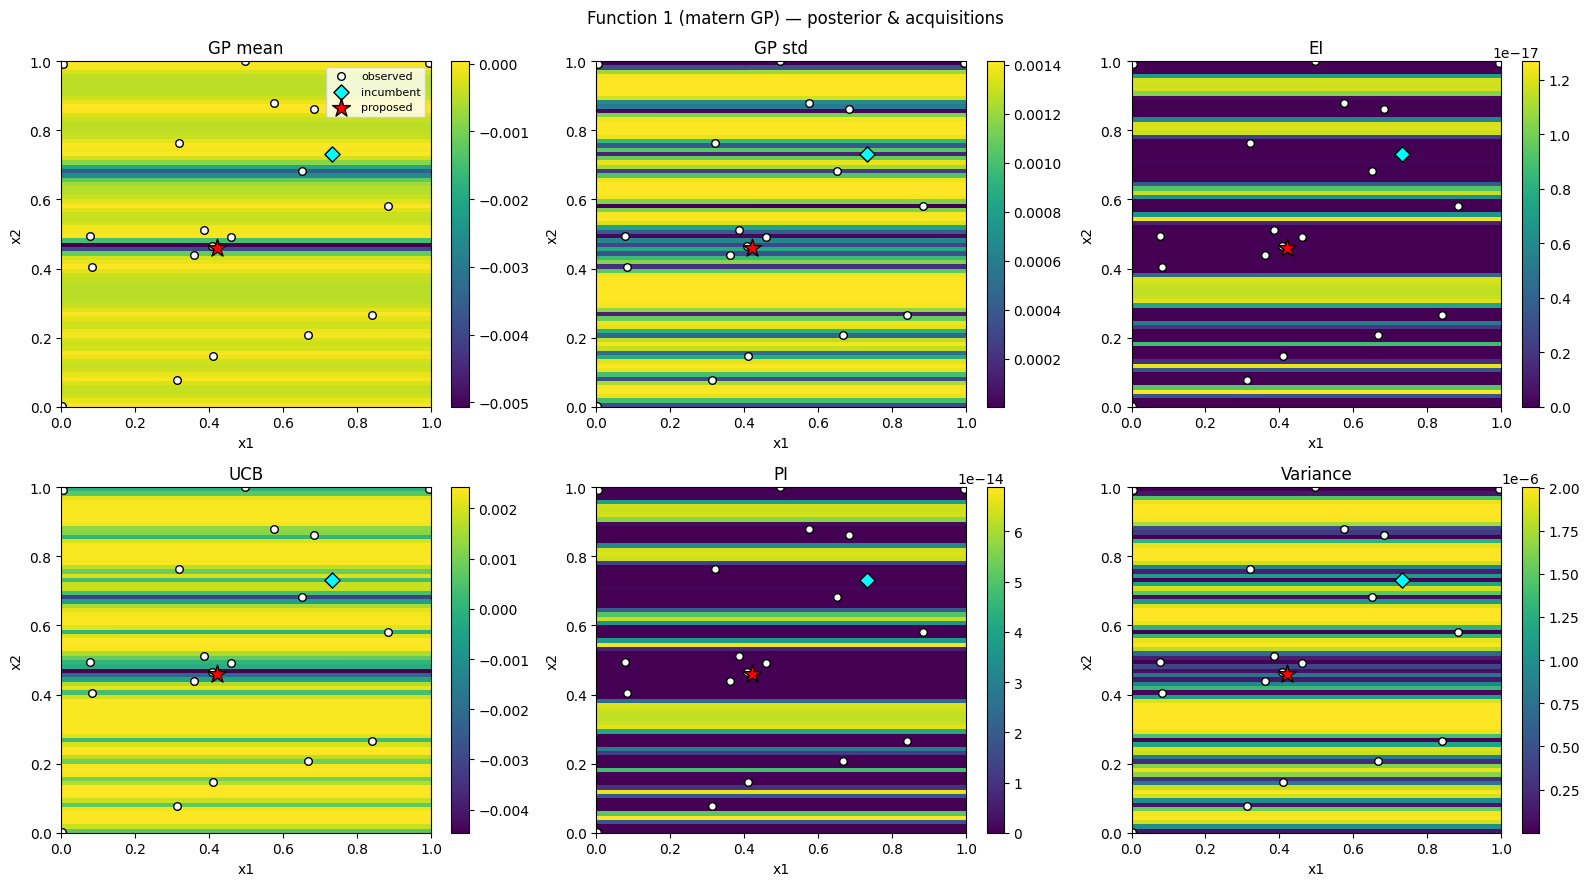

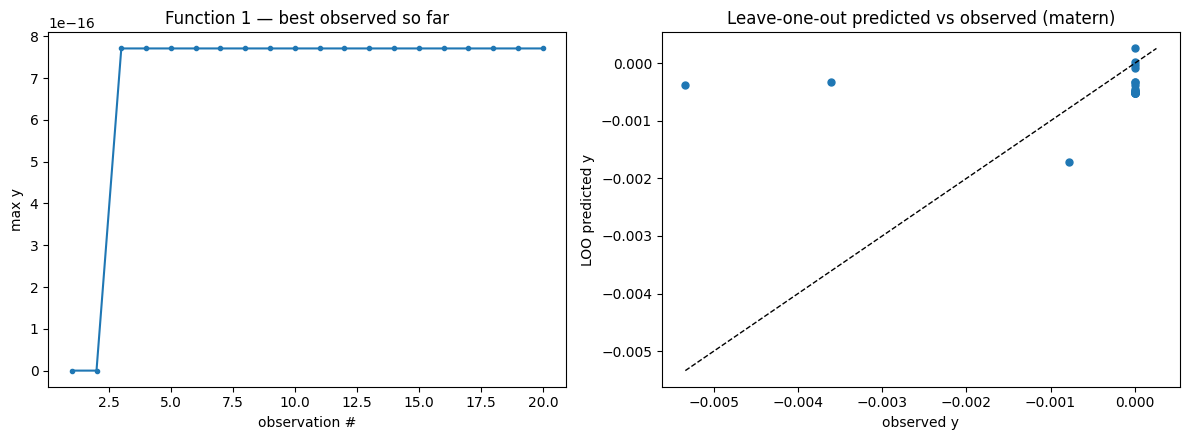

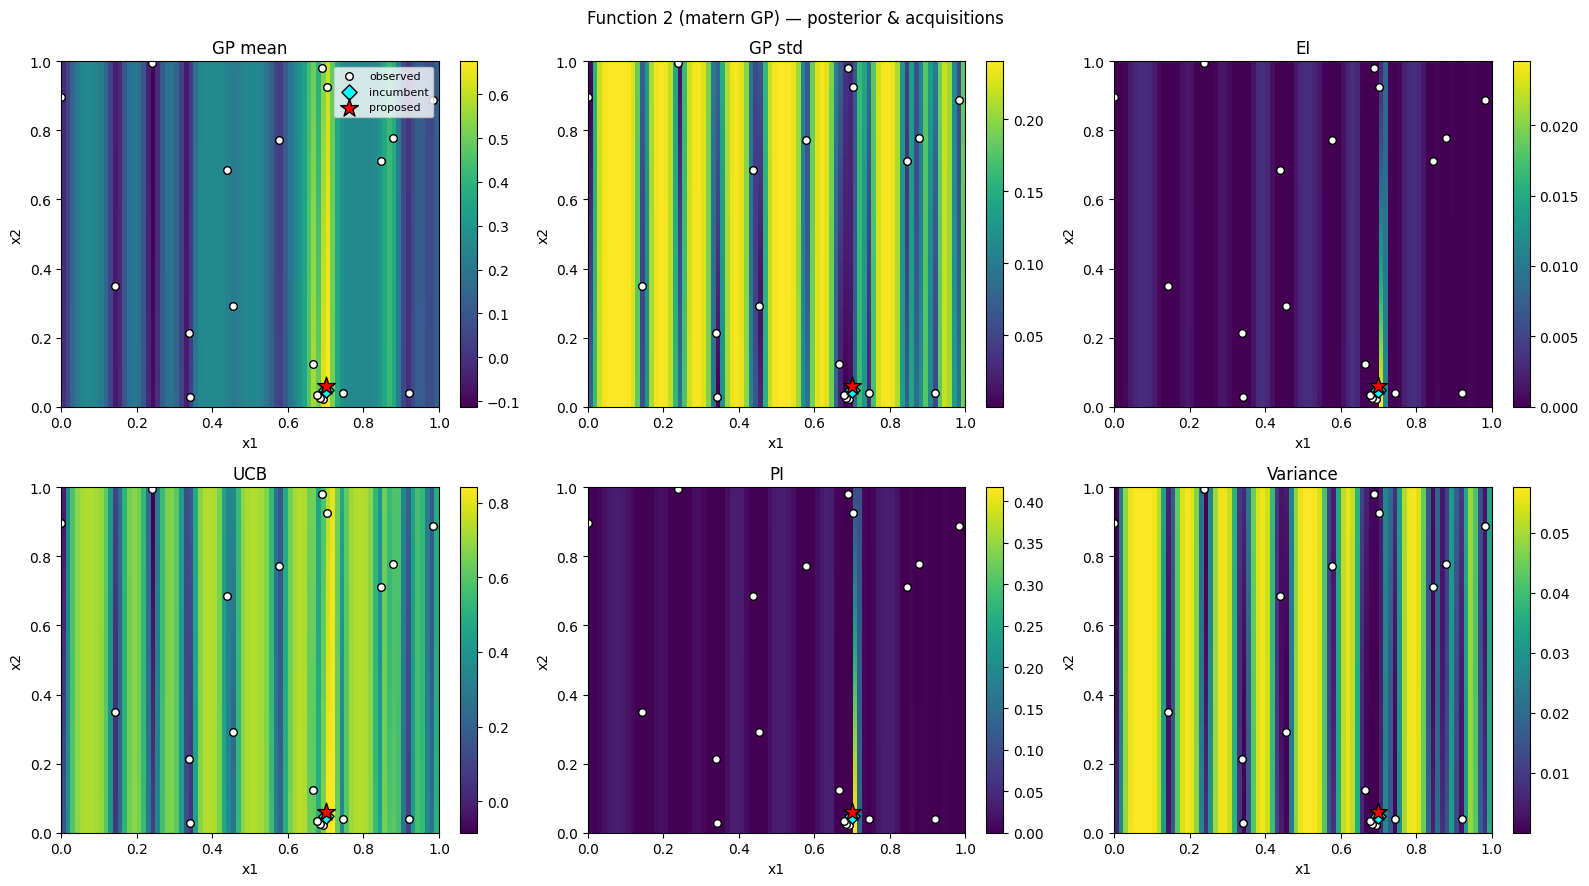

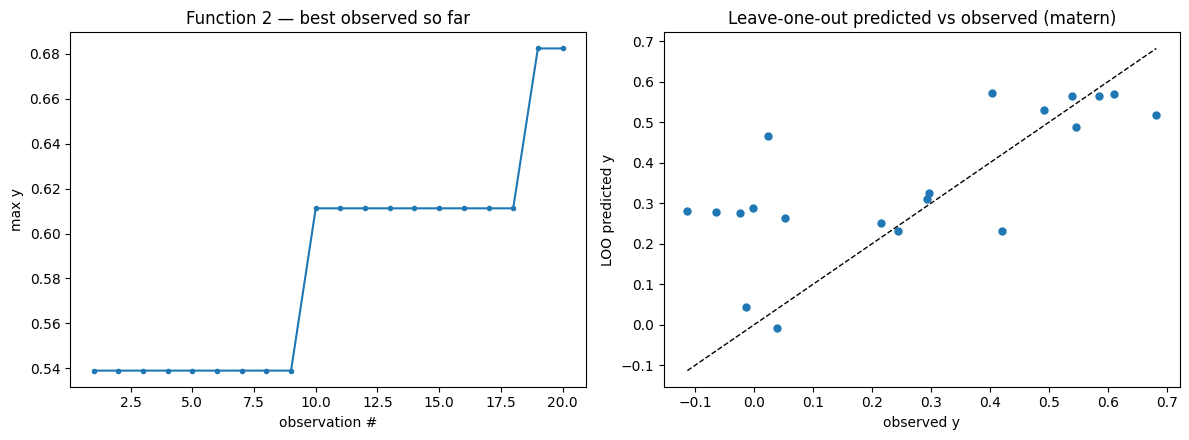

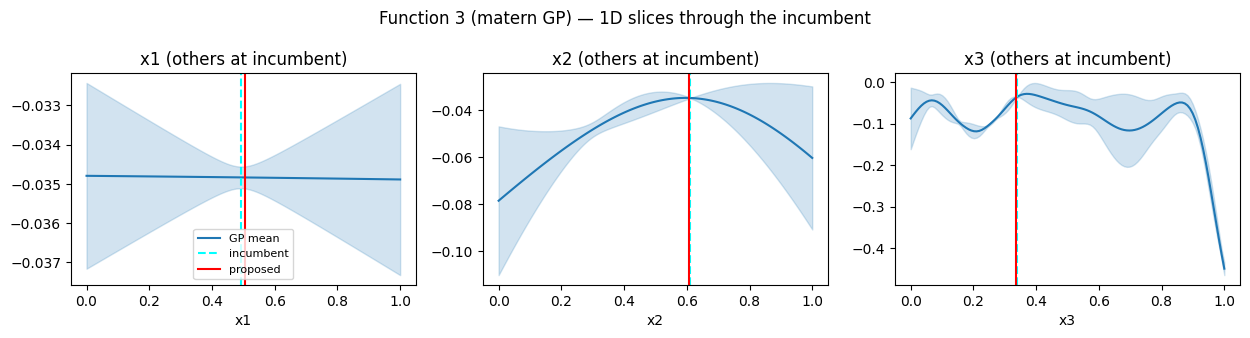

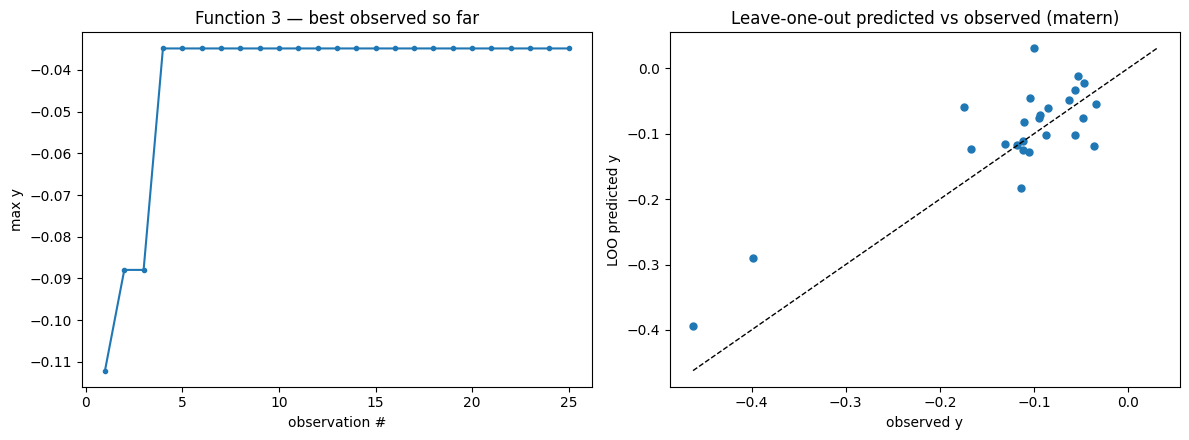

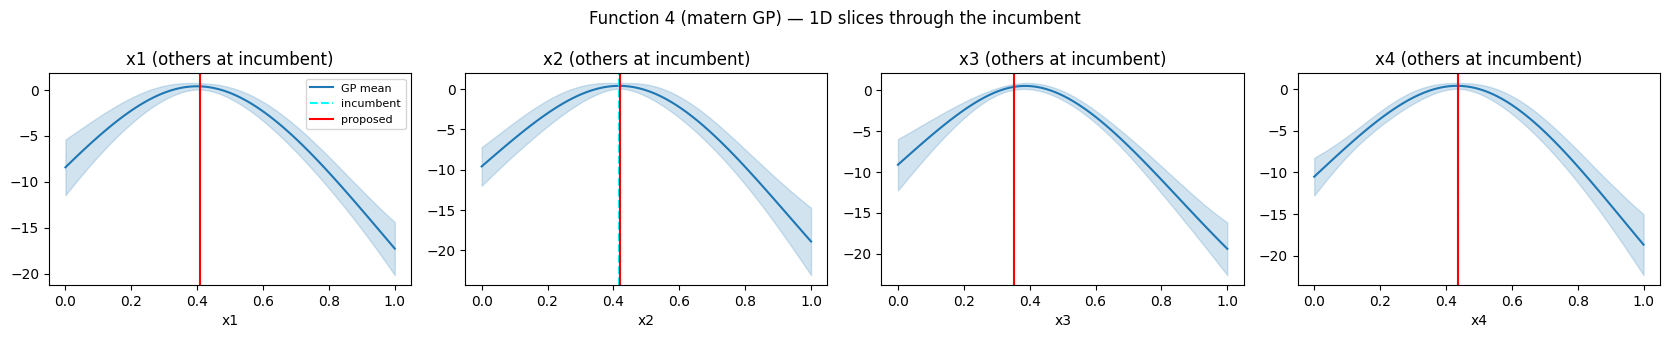

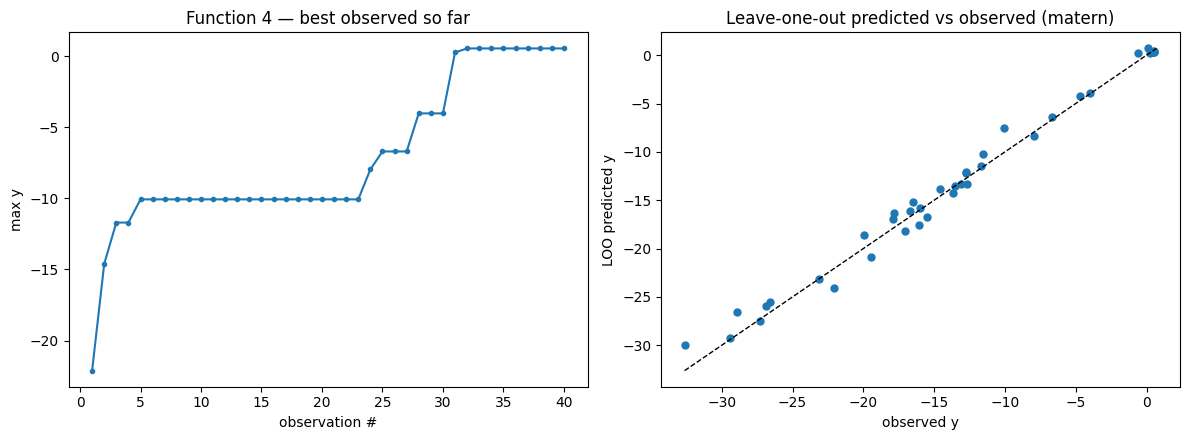

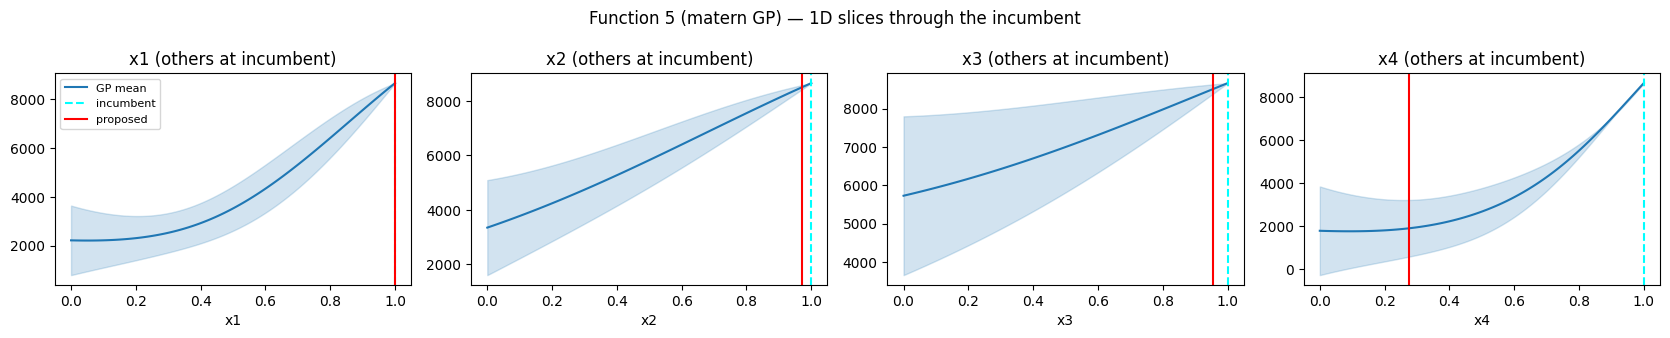

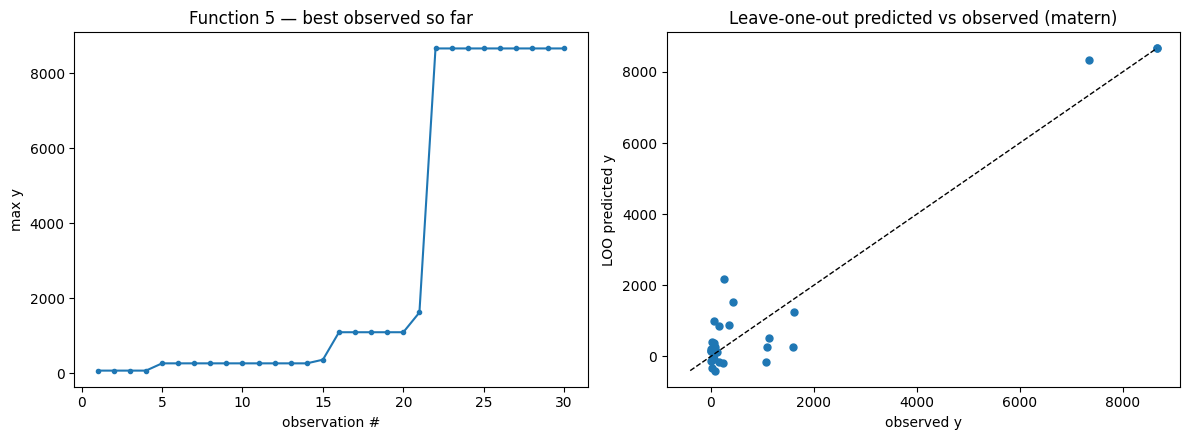

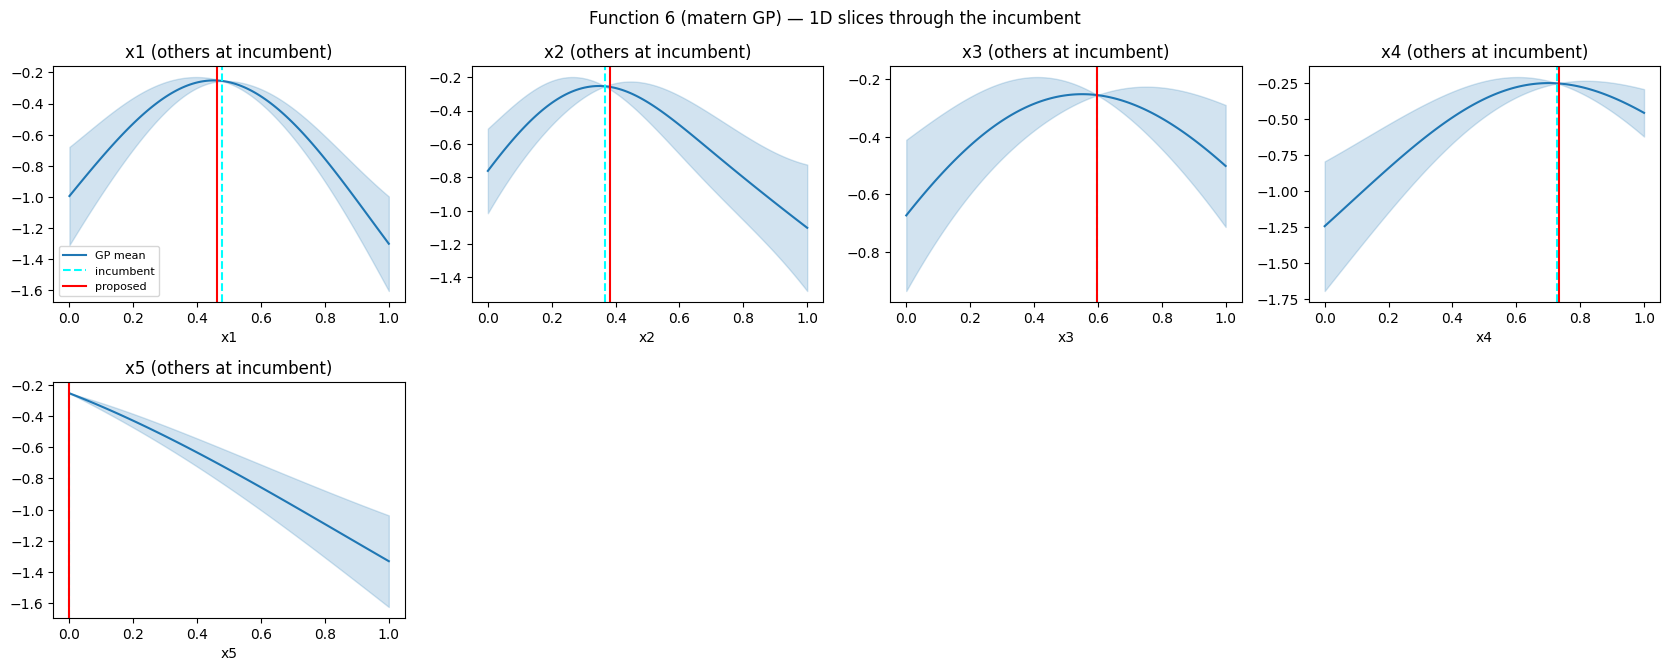

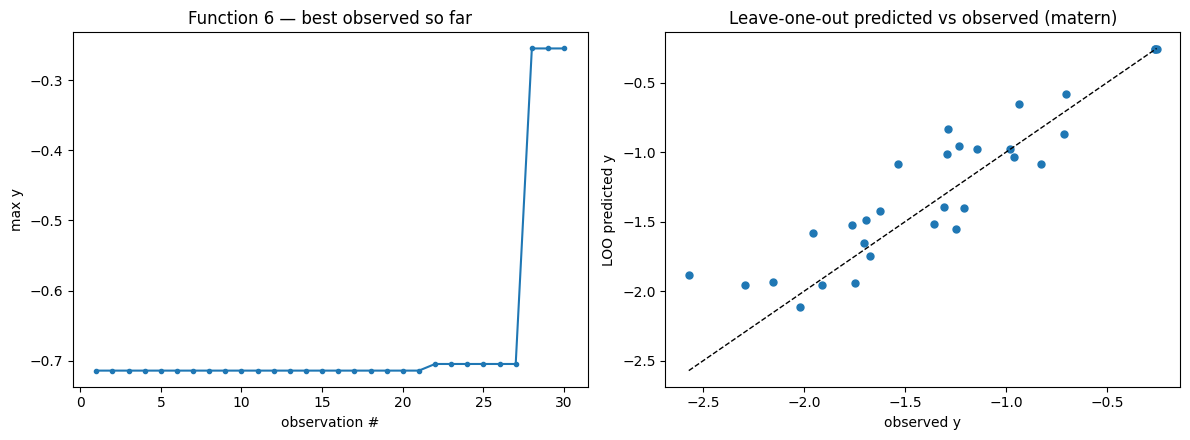

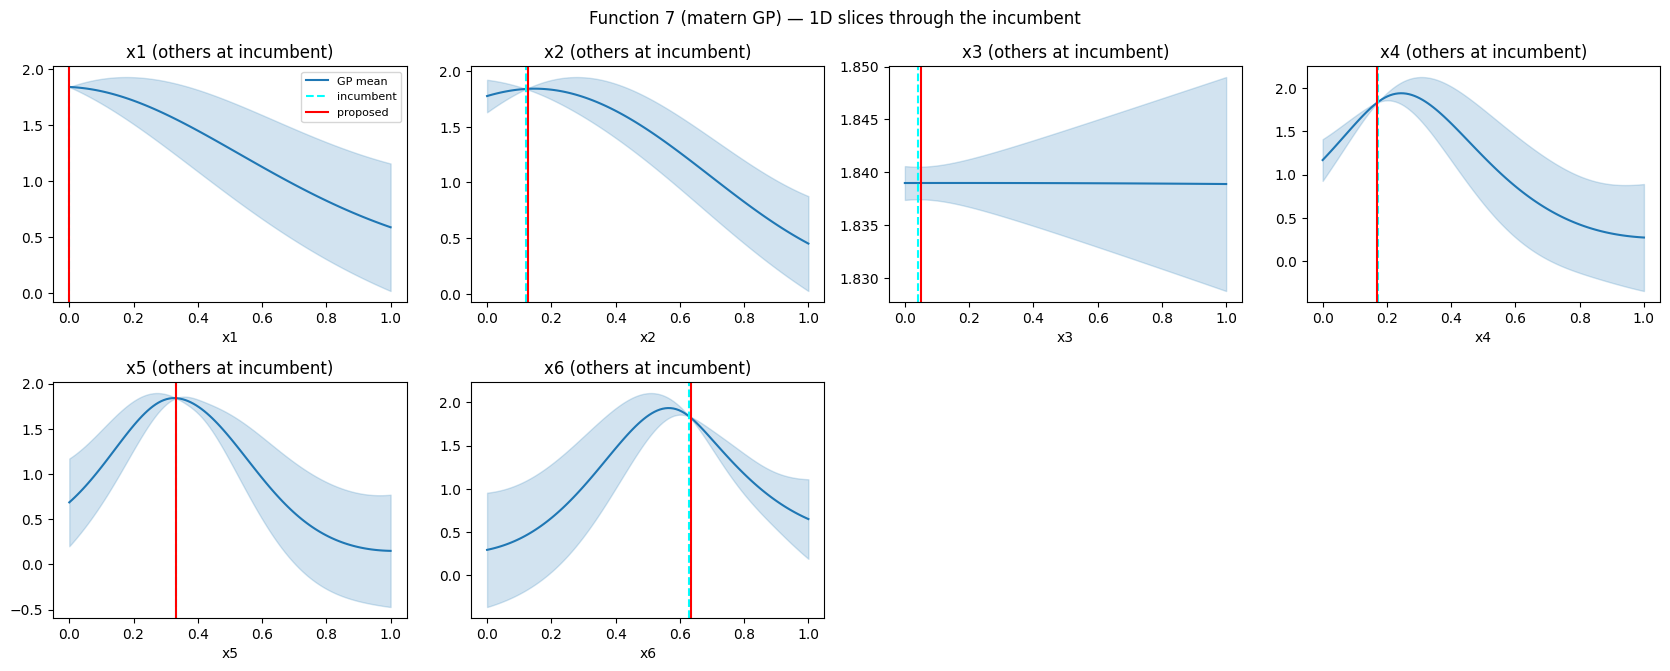

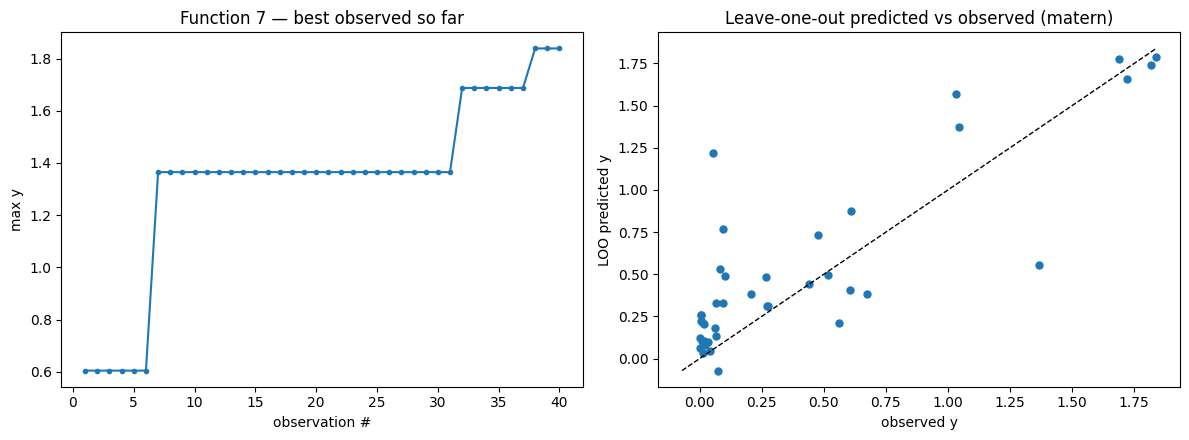

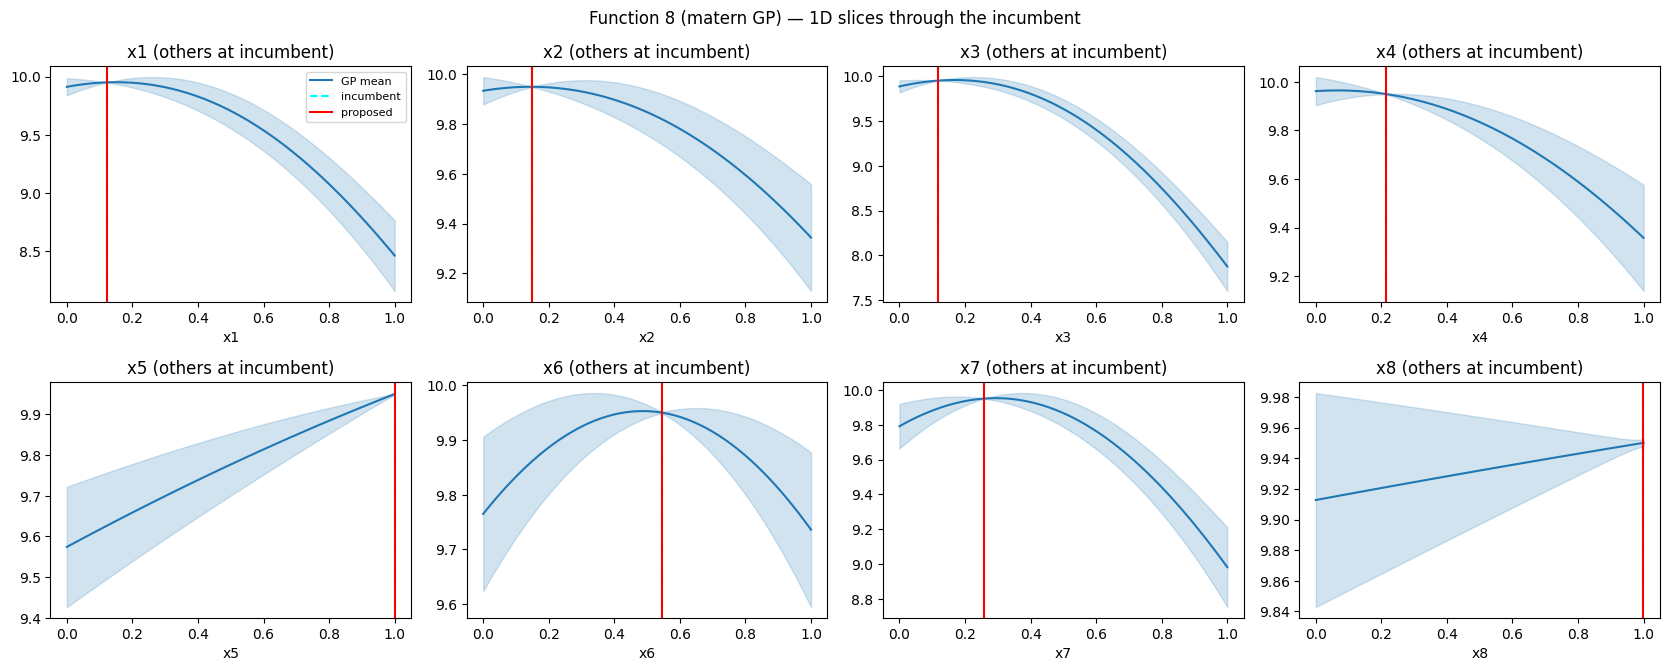

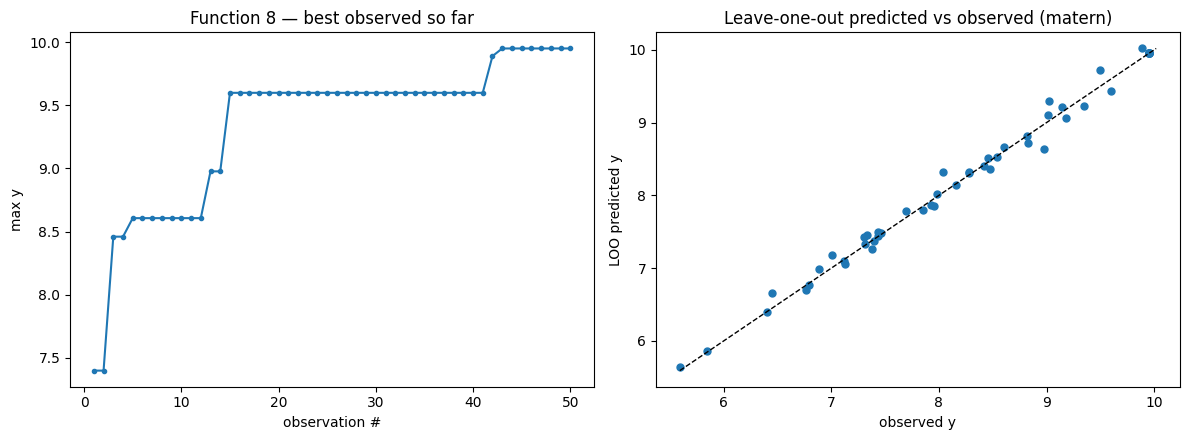

In [5]:
for fid in bo.FUNC_IDS:
    r = results[fid]; m = r.get("model") or bo.fit(fid)
    if m.d == 2:
        bo.plot_2d(m, proposed=r["x"], save=f"{OUTDIR}/f{fid}_2d.png")
    else:
        bo.plot_slices(m, proposed_u=r["u"], save=f"{OUTDIR}/f{fid}_slices.png")
    bo.plot_diagnostics(m, save=f"{OUTDIR}/f{fid}_diag.png")
    plt.show()


## 4. Submission strings - copy one per function into the portal

In [6]:
for fid in bo.FUNC_IDS:
    print(f"f{fid}:  {results[fid]['submission']}")

f1:  0.420000-0.460000
f2:  0.700193-0.060735
f3:  0.504829-0.606490-0.337197
f4:  0.407788-0.419035-0.352666-0.437693
f5:  0.999792-0.970769-0.956070-0.276667
f6:  0.460608-0.382045-0.597029-0.734950-0.000000
f7:  0.000000-0.125952-0.049277-0.169247-0.330694-0.635571
f8:  0.121750-0.148801-0.117912-0.213080-0.999999-0.545195-0.258480-0.997538


## 5. Write the weekly reflection scaffold
Creates `weekly/reflections/weekNN.md` if it doesn't exist yet. It will **not** overwrite a
reflection you've already written (pass `overwrite=True` to force a fresh scaffold).

In [7]:
path = bo.render_reflection(WEEK, results)   # won't overwrite an already-written reflection
print("reflection ->", path)


reflection -> /Users/jp/PycharmProjects/MachineLearning/Capstone/weekly/reflections/week11.md


## 6. After the portal returns each y - record results for next round
Fill in the returned outputs below, run the cell, then bump `WEEK` and re-run the notebook
next module. `append_result` grows each function's CSV by one row.

In [8]:
# Week 11 portal returns - already saved into data/fN.csv outside the notebook.
# returned_y = {
#     1: 0.002698042046872221,
#     2: 0.6486229115784087,
#     3: -0.040737605592491954,
#     4: 0.4905673047040904,
#     5: 3552.3070915229414,
#     6: -0.14968264737338183,
#     7: 1.8573204141374728,
#     8: 9.9499491367971,
# }
#
# BEST ROUND OF THE PROJECT - FOUR NEW BESTS:
#   f1 +0.0027 at (0.42, 0.46) - FIRST POSITIVE READING EVER. The hot-box probe found the
#      source side. Sign flips from -0.0053 at (0.407, 0.466) to +0.0027 at (0.42, 0.46)
#      within a distance of ~0.015: the structure is sharp and we are right on top of it.
#   f6 -0.1497 (+0.105) - the pocket keeps improving toward zero (brief: maximise toward 0).
#   f7 1.8573 (+0.018) - second improvement from the same pocket.
#   f8 9.9499491 - 5th consecutive marginal MES improvement.
#
# The rest:
#   f2 0.649 (close, winner 0.682 stands)   f3 -0.041 (close, seed -0.035 stands)
#   f4 0.491 (razor peak: even +/-0.005 costs 0.05 - the exact W2 coords are the lock)
#   f5 3552 at (0.9998, 0.97, 0.956, 0.277) - biggest non-corner value seen; consistent
#      with a ridge running toward the (1,1,1,1) peak. Corner remains king.
# for fid, y in returned_y.items():
#     bo.append_result(fid, results[fid]["x"], y)
# print("saved; dataset sizes now:", {fid: len(bo.load(fid)[1]) for fid in bo.FUNC_IDS})
